# 21 — Las 7 ligas con el percentil del fantasy completo

El notebook 19 comparó las siete ligas con medianas de equipo y tasas; el 20 completó el puntaje fantasy con la mitad
defensiva. Este usa la pieza que salió de ahí: el **percentil del fantasy completo dentro de la liga-temporada-posición**
(`pct_pts_completo`), que es lo único que permite poner en la misma escala a un defensa de la Eredivisie 2016-17 y a
uno de la Premier 2024-25.

**Lo primero que hay que entender es qué NO se puede hacer con el percentil**: por construcción, el percentil medio de
toda liga es 50. Comparar percentiles medios entre ligas no dice absolutamente nada. Lo que sí informa:

1. **¿Qué tanto se repite el percentil de un año al siguiente?** Es la prueba de siempre del proyecto, pero quitando
   de en medio el ambiente de la liga y de la época.
2. **¿Qué pasa cuando un jugador se muda de liga?** Si al llegar a la Premier su percentil cae, es que ahí los rivales
   por el puesto son mejores. Con eso se puede ordenar las siete ligas por dificultad — con mucho cuidado, porque
   quien se muda no es una muestra al azar.
3. **¿El plantel explica los puntos del equipo?** Con puntos brutos esta pregunta no era comparable entre ligas
   (una liga más goleadora reparte más puntos); con percentiles sí.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

LIGAS = ["Liga MX", "Premier League", "La Liga", "Serie A", "Bundesliga", "Ligue 1", "Eredivisie"]
COLOR = dict(zip(LIGAS, estilo.CATEGORICA))          # el mismo color por liga que en los notebooks 19 y 20
POSICIONES = liga.POSICIONES
NOMBRE_POS = {"GK": "Porteros", "DF": "Defensas", "MF": "Mediocampistas", "FW": "Delanteros"}
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

## 1. Los datos: el percentil del fantasy completo

`fantasy.percentil_completo` aplica dos reglas: solo entran las filas con `def_completo` (antes de 2014-15 no hay goles
recibidos en cancha y antes de 2016-17 no hay penales atajados) y el percentil se calcula dentro de cada
liga-temporada-posición, entre quienes pasaron de 900 minutos.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_defensivos(fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas)))
jt["pct_completo"] = fantasy.percentil_completo(jt)

print(f"{jt['pct_completo'].notna().sum():,} jugador-temporada con percentil completo, "
      f"de {len(jt):,} del panel")
# Comprobación de que el percentil hace lo que promete: la media de CADA liga tiene que dar ~50.
print("\nPercentil medio por liga (por construcción, todas ~50 — por eso no se pueden comparar así):")
print(jt.groupby("league")["pct_completo"].mean().reindex(LIGAS).round(1).to_string())

25,484 jugador-temporada con percentil completo, de 59,452 del panel

Percentil medio por liga (por construcción, todas ~50 — por eso no se pueden comparar así):
league
Liga MX           50.7
Premier League    50.6
La Liga           50.6
Serie A           50.6
Bundesliga        50.7
Ligue 1           50.6
Eredivisie        50.7


25,484 jugador-temporada tienen percentil completo: los que cumplen las tres condiciones (datos defensivos completos,
900+ minutos y una liga-temporada-posición con suficientes rivales). Y ahí está la comprobación que hay que hacer
antes de cualquier otra cosa: **el percentil medio de las siete ligas es 50.6-50.7**. No es un hallazgo, es la
definición. Cualquier análisis que "descubra" que una liga tiene jugadores con mejor percentil que otra estaría
midiendo su propio método.

## 2. ¿Se repite el percentil de un año al siguiente?

La prueba de siempre, ahora sobre el percentil. La comparación interesante es contra la estabilidad de los **puntos**
del notebook 20: los puntos brutos llevan dentro una parte estable que no es del jugador (el ambiente de su liga y de
su época, y cuánto juega), y el percentil la quita.

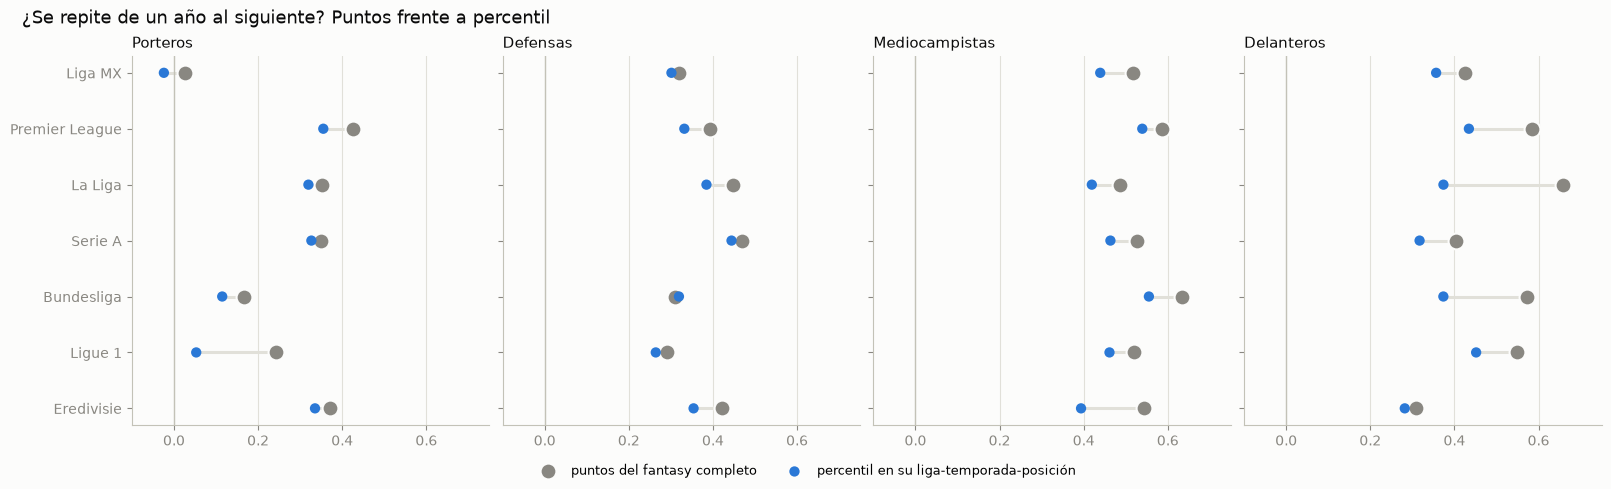

Media de las 7 ligas:
          estab_completo  estab_percentil
posicion                                 
GK                 0.276            0.211
DF                 0.379            0.343
MF                 0.545            0.467
FW                 0.500            0.370


In [3]:
comp = liga.comparativa_posiciones(jt, LIGAS)

fig, axs = plt.subplots(1, 4, figsize=(16, 4.8), sharex=True, constrained_layout=True)
orden = LIGAS[::-1]
for ax, pos in zip(axs, POSICIONES):
    d = comp[comp["posicion"] == pos].set_index("league").reindex(orden)
    y = np.arange(len(orden))
    for i, (puntos, percentil) in enumerate(zip(d["estab_completo"], d["estab_percentil"])):
        if np.isfinite(puntos) and np.isfinite(percentil):
            ax.plot([puntos, percentil], [i, i], color=estilo.REJILLA, linewidth=2.2, zorder=1)
    ax.scatter(d["estab_completo"], y, s=130, color=estilo.TENUE, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
               zorder=3, label="puntos del fantasy completo")
    ax.scatter(d["estab_percentil"], y, s=55, color=estilo.AZUL, edgecolors="none", zorder=4,
               label="percentil en su liga-temporada-posición")
    ax.axvline(0, color=estilo.EJE, linewidth=1)
    ax.set_yticks(y, orden if pos == POSICIONES[0] else [""] * len(orden))
    ax.set_title(NOMBRE_POS[pos])
    ax.set_xlim(-0.1, 0.75)
    ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
fig.legend(*axs[0].get_legend_handles_labels(), loc="outside lower center", ncols=2, fontsize=9)
fig.suptitle("¿Se repite de un año al siguiente? Puntos frente a percentil", x=0.01, ha="left", fontsize=13,
             color=estilo.TINTA)
fig.savefig(FIGURAS / "percentil_estabilidad.png", dpi=150)
plt.show()

print("Media de las 7 ligas:")
print(comp.groupby("posicion")[["estab_completo", "estab_percentil"]].mean().reindex(POSICIONES).round(3).to_string())

El percentil se repite **menos** que los puntos, en las siete ligas y en las cuatro posiciones: porteros 0.28 → 0.21,
defensas 0.38 → 0.34, mediocampistas 0.55 → 0.47 y delanteros 0.50 → 0.37.

No es que el percentil sea peor: es que es más honesto. Los puntos brutos llevan dentro una parte estable que **no es
del jugador** —el ambiente goleador de su liga, la época, el calendario— y esa parte se repite sola año tras año. Al
comparar a cada jugador solo contra sus rivales de puesto de esa misma liga y ese mismo año, esa ayuda desaparece.
Dicho de otro modo: parte de lo que parecía "este jugador repite" era "su contexto repite".

Hay que anotar también un efecto mecánico en contra del percentil: **comprime los extremos**. Un delantero que un año
está en el percentil 99.5 y al siguiente en el 99.0 fue igual de dominante las dos veces, pero en la escala de
percentiles casi no se mueve, y eso baja la correlación. Por eso la caída más grande es la de los delanteros, que son
quienes más se amontonan arriba del todo.

El orden entre posiciones no cambia (mediocampistas 0.47 > delanteros 0.37 > defensas 0.34 > porteros 0.21), pero las
distancias se acortan mucho: con puntos, un delantero parecía bastante más "medible" que un defensa (0.50 contra
0.38); con percentiles casi están a la par.

## 3. La escalera: ¿qué liga es más difícil?

Aquí está el uso que justifica todo el percentil. Si un jugador pasa de una liga a otra y su percentil cae, es que en
la liga nueva los rivales por su puesto son mejores.

**El problema que hay que resolver antes**: quien se muda fue elegido por su última temporada. Una temporada
excepcional le consigue el traspaso, y al año siguiente su percentil baja **por pura regresión a la media**, aunque la
liga nueva sea idéntica a la vieja. Medir la caída sin más sería confundir la selección con la dificultad.

**El control**: no se compara contra "quedarse igual" sino contra **quien cambió de club dentro de su misma liga**.
Ese grupo tiene la misma selección (también se mudó por una buena temporada) y el mismo trastorno de adaptarse a un
equipo nuevo; lo único que no hace es cambiar de liga. Sobre él se ajusta la recta
`percentil_siguiente = a + b·percentil`, y cada mudanza internacional se mide como residuo contra esa recta.

606 cambios de liga con 1,500+ minutos en las dos temporadas
Control (cambió de club, no de liga; n = 1,180): percentil_siguiente = 40.7 + 0.35 · percentil
  Es decir: quien viene del percentil 90 promedia 72 al año siguiente SIN cambiar de liga. Esa es la caída que no hay que cobrarle a la liga nueva.


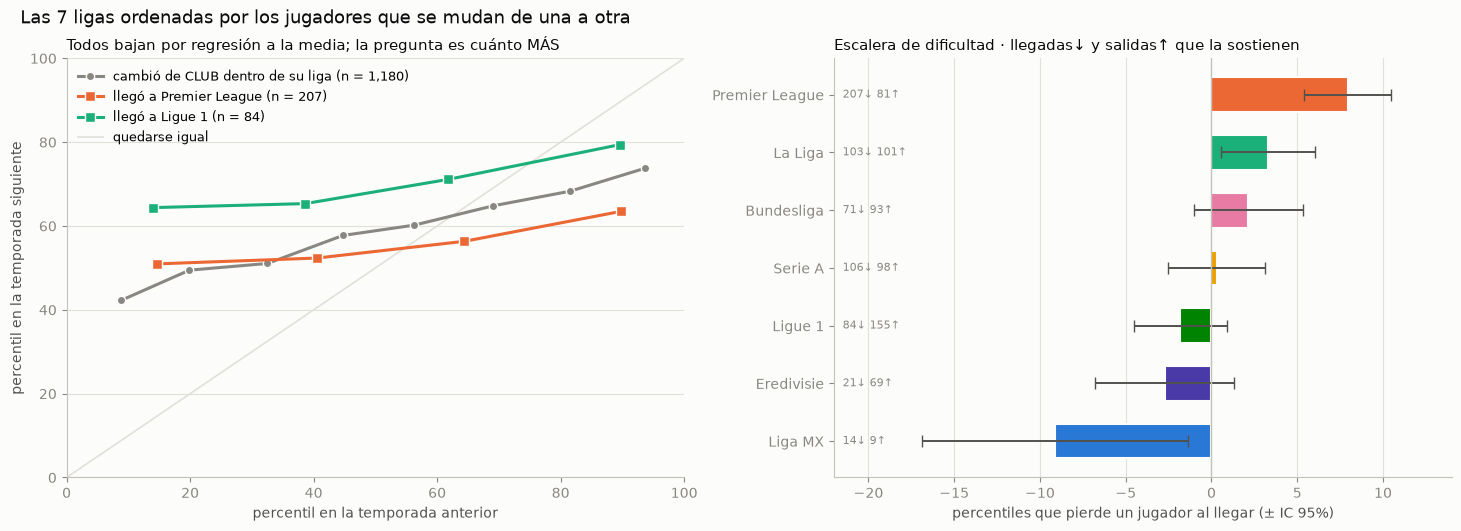

,league,dificultad,ee,llegadas,salidas
0,Premier League,7.94,1.29,207,81
1,La Liga,3.28,1.40,103,101
2,Bundesliga,2.15,1.62,71,93
3,Serie A,0.29,1.45,106,98
4,Ligue 1,-1.82,1.39,84,155
5,Eredivisie,-2.73,2.06,21,69
6,Liga MX,-9.13,3.95,14,9


In [4]:
movimientos, escalera = liga.escalera_ligas(jt, LIGAS)
print(f"{len(movimientos):,} cambios de liga con 1,500+ minutos en las dos temporadas")

# Cómo se ve el control y por qué hace falta: medias por tramo del percentil de partida.
x = jt[(jt["minutes"] >= 1500) & jt["pct_completo"].notna()][
    ["id_jugador", "temporada_inicio", "league", "equipo_principal_id", "pct_completo"]]
pares = x.merge(x.assign(temporada_inicio=x["temporada_inicio"] - 1), on=["id_jugador", "temporada_inicio"],
                suffixes=("", "_sig"))
control = pares[(pares["league"] == pares["league_sig"])
                & (pares["equipo_principal_id"] != pares["equipo_principal_id_sig"])]
pendiente, corte = np.polyfit(control["pct_completo"], control["pct_completo_sig"], 1)
print(f"Control (cambió de club, no de liga; n = {len(control):,}): "
      f"percentil_siguiente = {corte:.1f} + {pendiente:.2f} · percentil")
print(f"  Es decir: quien viene del percentil 90 promedia {corte + pendiente * 90:.0f} al año siguiente SIN cambiar "
      f"de liga. Esa es la caída que no hay que cobrarle a la liga nueva.")

fig, axs = plt.subplots(1, 2, figsize=(14.5, 5.2), constrained_layout=True)
# Panel A: la recta de control y, encima, quienes llegaron a la liga más dura y a la más blanda.
tramos = pd.cut(control["pct_completo"], np.arange(0, 101, 12.5))
medias = control.groupby(tramos, observed=True).agg(x=("pct_completo", "mean"), y=("pct_completo_sig", "mean"))
axs[0].plot(medias["x"], medias["y"], color=estilo.TENUE, linewidth=2.2, marker="o", markersize=6,
            markeredgecolor=estilo.SUPERFICIE, label=f"cambió de CLUB dentro de su liga (n = {len(control):,})")
for nombre, color in [("Premier League", estilo.NARANJA), ("Ligue 1", estilo.AQUA)]:
    d = movimientos[movimientos["league_sig"] == nombre]
    m = d.groupby(pd.cut(d["pct_completo"], np.arange(0, 101, 25)), observed=True).agg(
        x=("pct_completo", "mean"), y=("pct_completo_sig", "mean"))
    axs[0].plot(m["x"], m["y"], color=color, linewidth=2.2, marker="s", markersize=7,
                markeredgecolor=estilo.SUPERFICIE, label=f"llegó a {nombre} (n = {len(d)})")
axs[0].plot([0, 100], [0, 100], color=estilo.REJILLA, linewidth=1.2, zorder=0, label="quedarse igual")
axs[0].set(xlabel="percentil en la temporada anterior", ylabel="percentil en la temporada siguiente",
           xlim=(0, 100), ylim=(0, 100))
axs[0].set_title("Todos bajan por regresión a la media; la pregunta es cuánto MÁS")
axs[0].legend(loc="upper left", fontsize=9)
estilo.rejilla_y(axs[0])

# Panel B: la escalera con su intervalo de confianza del 95%.
e = escalera.iloc[::-1]
y = np.arange(len(e))
axs[1].barh(y, e["dificultad"], color=[COLOR[n] for n in e["league"]], height=0.6,
            edgecolor=estilo.SUPERFICIE, linewidth=1.5)
axs[1].errorbar(e["dificultad"], y, xerr=1.96 * e["ee"], fmt="none", ecolor=estilo.TINTA_2, elinewidth=1.4,
                capsize=4)
# Cuántos traspasos sostienen cada cifra, alineados a la izquierda para que no choquen con las barras de error.
for i, fila in enumerate(e.itertuples()):
    axs[1].text(-21.5, i, f"{fila.llegadas}↓ {fila.salidas}↑", va="center", ha="left", fontsize=8,
                color=estilo.TENUE)
axs[1].axvline(0, color=estilo.EJE, linewidth=1)
axs[1].set_yticks(y, e["league"])
axs[1].set_xlim(-22, 14)
axs[1].set_xlabel("percentiles que pierde un jugador al llegar (± IC 95%)")
axs[1].set_title("Escalera de dificultad · llegadas↓ y salidas↑ que la sostienen")
axs[1].grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
axs[1].set_axisbelow(True)
fig.suptitle("Las 7 ligas ordenadas por los jugadores que se mudan de una a otra", x=0.01, ha="left", fontsize=13,
             color=estilo.TINTA)
fig.savefig(FIGURAS / "percentil_escalera.png", dpi=150)
plt.show()

escalera.round(2)

La recta de control lo dice todo: quien cambió de club **sin salir de su liga** y venía del percentil 90 promedia 72
al año siguiente. Esos 18 percentiles de caída son regresión a la media y selección, no dificultad, y es exactamente
lo que había que descontar antes de cobrarle nada a la liga nueva. En el panel izquierdo se ve cómo, sobre esa misma
recta, quien llega a la Premier queda sistemáticamente por debajo y quien llega a la Ligue 1 por encima.

La escalera resultante, en percentiles que cuesta llegar:

| Liga | Dificultad | Llegadas / salidas |
|---|---|---|
| Premier League | **+7.9** | 207 / 81 |
| La Liga | +3.3 | 103 / 101 |
| Bundesliga | +2.2 | 71 / 93 |
| Serie A | +0.3 | 106 / 98 |
| Ligue 1 | −1.8 | 84 / 155 |
| Eredivisie | −2.7 | 21 / 69 |
| Liga MX | −9.1 | 14 / 9 |

La Premier está sola arriba: llegar ahí cuesta unos 8 percentiles más que cambiar de club dentro de la propia liga.
El orden coincide con lo que cualquiera esperaría, lo cual es buena señal de que el método no está inventando nada,
pero el valor de esto no es el orden sino **el tamaño**: la distancia entre la Premier y la Ligue 1 es de unos 10
percentiles, no de 40.

Las columnas de llegadas y salidas cuentan otra historia: la Ligue 1 exporta casi el doble de lo que importa
(155 contra 84) y la Premier importa dos veces y media lo que exporta (207 contra 81). La Eredivisie y la Liga MX
tienen tan pocos movimientos que sus cifras hay que leerlas con mucha reserva — la de la Liga MX se sostiene en 23
traspasos en total.

In [5]:
# ¿Qué diferencias son de verdad distinguibles? Remuestreo de los 606 traspasos (bootstrap).
rng = np.random.default_rng(11)
X = np.column_stack([(movimientos["league"] == n).astype(float) - (movimientos["league_sig"] == n).astype(float)
                     for n in LIGAS])
y = movimientos["residuo"].values
muestras = np.array([np.linalg.lstsq(X[i], y[i], rcond=None)[0]
                     for i in (rng.integers(0, len(y), len(y)) for _ in range(2000))])

comparaciones = [("Premier League", "Liga MX"), ("Premier League", "Ligue 1"), ("Premier League", "La Liga"),
                 ("La Liga", "Serie A"), ("Serie A", "Ligue 1")]
print("Diferencias entre pares de ligas, con intervalo de confianza del 95% (bootstrap de 2,000 remuestreos):")
for a, b in comparaciones:
    d = muestras[:, LIGAS.index(a)] - muestras[:, LIGAS.index(b)]
    bajo, alto = np.percentile(d, [2.5, 97.5])
    marca = "distinguible" if bajo > 0 or alto < 0 else "NO distinguible"
    print(f"  {a} − {b}: {d.mean():+5.1f} percentiles  (IC95 {bajo:+.1f} a {alto:+.1f})  → {marca}")

Diferencias entre pares de ligas, con intervalo de confianza del 95% (bootstrap de 2,000 remuestreos):
  Premier League − Liga MX: +17.0 percentiles  (IC95 +6.1 a +27.6)  → distinguible
  Premier League − Ligue 1:  +9.8 percentiles  (IC95 +6.3 a +13.3)  → distinguible
  Premier League − La Liga:  +4.7 percentiles  (IC95 +1.4 a +7.9)  → distinguible
  La Liga − Serie A:  +3.0 percentiles  (IC95 -0.4 a +6.5)  → NO distinguible
  Serie A − Ligue 1:  +2.1 percentiles  (IC95 -1.4 a +5.9)  → NO distinguible


Esta es la parte que evita leer la escalera como si fuera una tabla de posiciones. Solo tres de las cinco
comparaciones son distinguibles del cero:

- Premier − Liga MX: **+17.0** (IC95 +6.1 a +27.6) — real, pero con un margen enorme por los pocos traspasos.
- Premier − Ligue 1: **+9.8** (IC95 +6.3 a +13.3) — la más sólida del conjunto.
- Premier − La Liga: **+4.7** (IC95 +1.4 a +7.9) — sí, aunque por poco.
- La Liga − Serie A: +3.0 (IC95 −0.4 a +6.5) — **no distinguible**.
- Serie A − Ligue 1: +2.1 (IC95 −1.4 a +5.9) — **no distinguible**.

Conclusión honesta: los datos separan claramente a la Premier del resto y ponen a la Liga MX al final, pero **las
cinco ligas de en medio no se pueden ordenar entre sí** con 606 traspasos. Y quedan confusiones que ningún control
arregla: quien se muda cambia también de edad, de rol y de nivel de equipo, y a la Premier no llega el mismo tipo de
jugador que llega a la Eredivisie.

## 4. ¿El plantel explica los puntos del equipo?

El proyecto ya había concluido que las medidas de "impacto" individual (on-off, puntos del equipo con él) son ruido de
un año al siguiente. Esta es la pregunta complementaria: sumar lo que cada jugador **produjo**, ¿sí explica lo que
consiguió el equipo? Y con el percentil se puede preguntar en las siete ligas a la vez.

        league  equipos_temporada  rho_plantel_puntos  rho_top20_puntos
       Liga MX                217               0.823             0.750
Premier League                240               0.825             0.794
       La Liga                240               0.784             0.750
       Serie A                240               0.853             0.833
    Bundesliga                216               0.857             0.797
       Ligue 1                234               0.786             0.750
    Eredivisie                216               0.861             0.821


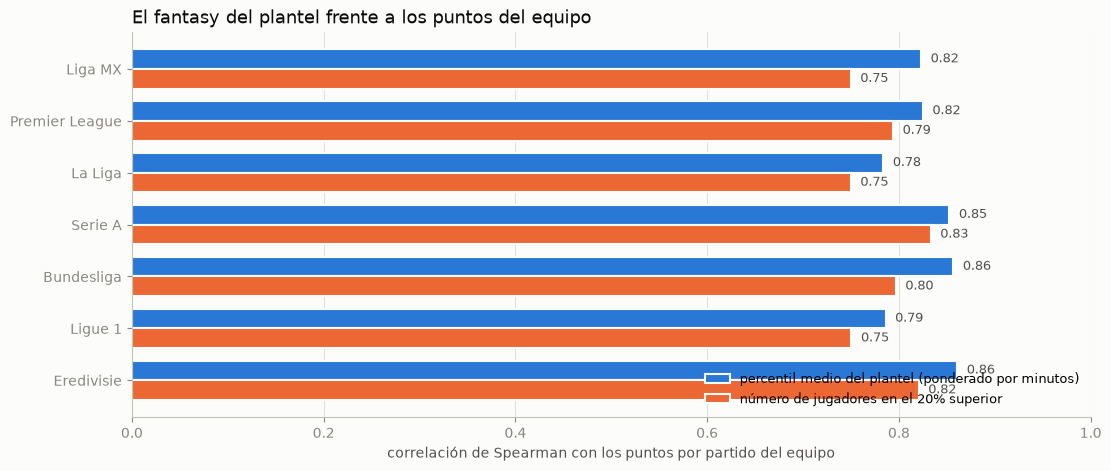

In [6]:
planteles = liga.plantel_vs_puntos(filas, jt, LIGAS)
print(planteles.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
y = np.arange(len(LIGAS))
d = planteles.set_index("league").reindex(LIGAS)
ax.barh(y - 0.19, d["rho_plantel_puntos"], 0.38, color=estilo.AZUL, edgecolor=estilo.SUPERFICIE, linewidth=1.5,
        label="percentil medio del plantel (ponderado por minutos)")
ax.barh(y + 0.19, d["rho_top20_puntos"], 0.38, color=estilo.NARANJA, edgecolor=estilo.SUPERFICIE, linewidth=1.5,
        label="número de jugadores en el 20% superior")
for i, (a, b) in enumerate(zip(d["rho_plantel_puntos"], d["rho_top20_puntos"])):
    ax.text(a + 0.01, i - 0.19, f"{a:.2f}", va="center", fontsize=9, color=estilo.TINTA_2)
    ax.text(b + 0.01, i + 0.19, f"{b:.2f}", va="center", fontsize=9, color=estilo.TINTA_2)
ax.set_yticks(y, LIGAS)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("correlación de Spearman con los puntos por partido del equipo")
ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("El fantasy del plantel frente a los puntos del equipo", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "percentil_plantel.png", dpi=150)
plt.show()

El percentil medio del plantel explica los puntos del equipo con una correlación de **0.78 a 0.86 en las siete
ligas**, sin una sola excepción. La Eredivisie (0.86), la Bundesliga (0.86) y la Serie A (0.85) arriba; La Liga (0.78)
y la Ligue 1 (0.79) abajo, con poca diferencia entre todas.

Conviene ser claro sobre qué tiene y qué no tiene de sorprendente. Buena parte es **mecánica**: los puntos fantasy se
construyen con goles, asistencias y porterías a cero, que son los mismos sucesos que ganan partidos. Que la suma de lo
que hicieron los jugadores se parezca a lo que consiguió el equipo es, sobre todo, una comprobación de que la medida
no está rota.

Lo que sí es informativo son dos cosas. Primera, que el número sea **igual de alto en las siete ligas**: la relación
entre producción individual y resultado colectivo no es un rasgo de una liga concreta. Segunda, que el percentil
medio del plantel (0.78-0.86) le gane consistentemente al número de figuras en el 20% superior (0.75-0.83): para los
puntos pesa más tener un plantel entero decente que unos pocos jugadores excepcionales.

Y el contraste con el resto del proyecto es el que vale la pena guardar: las medidas de **impacto** individual
(on-off, puntos del equipo con él) no miden al jugador ni predicen nada, mientras que la suma de lo que cada jugador
**produjo** sí se corresponde con lo que logró el equipo.

## 5. Conclusiones

1. **El percentil no sirve para comparar ligas directamente** —su media es 50 en todas por construcción— pero sí para
   comparar a los jugadores que se mudan entre ellas, que es lo que se hizo aquí.

2. **El percentil se repite menos que los puntos** (delanteros 0.50 → 0.37, mediocampistas 0.55 → 0.47, defensas
   0.38 → 0.34, porteros 0.28 → 0.21) en las siete ligas. Parte de lo que parecía estabilidad del jugador era
   estabilidad de su contexto. La cifra en percentiles es la honesta, con la salvedad de que comprime los extremos y
   por eso castiga sobre todo a los delanteros.

3. **La escalera de dificultad**, medida con 606 traspasos y controlada con los 1,180 cambios de club dentro de la
   misma liga: Premier +7.9, La Liga +3.3, Bundesliga +2.2, Serie A +0.3, Ligue 1 −1.8, Eredivisie −2.7,
   Liga MX −9.1. Llegar a la Premier cuesta unos 8 percentiles.

4. **Pero solo la Premier y la Liga MX se separan del resto.** Las cinco ligas intermedias no son distinguibles entre
   sí, y la cifra de la Liga MX se sostiene en 23 traspasos. La escalera es una ordenación aproximada con márgenes,
   no un ranking.

5. **El control es la mitad del trabajo.** Sin él, cualquier análisis de traspasos confundiría la regresión a la
   media (18 percentiles de caída para quien venía del percentil 90, incluso sin cambiar de liga) con la dificultad
   de la liga de destino.

6. **El plantel explica los puntos en las siete ligas por igual** (0.78 a 0.86), y el promedio del plantel le gana al
   número de figuras. Buena parte de esa correlación es mecánica, pero el contraste con el on-off sigue en pie:
   la producción individual agregada sí se corresponde con el resultado del equipo; las medidas de "impacto" no.